1. Setup

In [1]:
# =========================================================
# Librerías base
# =========================================================
import os
import sys
import importlib
import joblib
import numpy as np
import pandas as pd

# SHAP y visualización
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Detecta la raíz del proyecto
# ---------------------------------------------------------
PROJECT_ROOT = os.path.abspath("..")

# ---------------------------------------------------------
# Agrega la raíz al path para importar config
# ---------------------------------------------------------
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# ---------------------------------------------------------
# Importa configuración
# ---------------------------------------------------------
import utils.config as config
importlib.reload(config)

print("FULL_ARTIFACTS_DIR:", config.FULL_ARTIFACTS_DIR)
print("SHAP_SAMPLE_SIZE:", config.SHAP_SAMPLE_SIZE)

FULL_ARTIFACTS_DIR: /home/bryan_santanderaragon/Proyecto_MBD/data/artifacts/full
SHAP_SAMPLE_SIZE: 1000


2. Cargar modelo y datos

In [2]:
# ---------------------------------------------------------
# Carga el mejor modelo multiclase full
# Aquí usamos XGBoost Full
# ---------------------------------------------------------
model = joblib.load(
    os.path.join(config.FULL_ARTIFACTS_DIR, "xgb_multiclass_full.pkl")
)

# ---------------------------------------------------------
# Carga datasets de prueba multiclase
# ---------------------------------------------------------
X_test = pd.read_parquet(
    os.path.join(config.FULL_ARTIFACTS_DIR, "X_test_full_multiclass.parquet")
)

y_test = pd.read_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "y_test_full_multiclass.csv")
).squeeze("columns")

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (4467805, 22)
y_test: (4467805,)


3. Cargar o reconstruir encoder del target

In [3]:
from sklearn.preprocessing import LabelEncoder

encoder_path = os.path.join(config.FULL_ARTIFACTS_DIR, "target_encoder_full_multiclass.pkl")

if os.path.exists(encoder_path):
    target_encoder = joblib.load(encoder_path)
    print("Encoder cargado desde archivo.")
else:
    print("Encoder no encontrado. Reconstruyendo desde dataset full...")
    df_full = pd.read_parquet(config.FULL_CONSOLIDATED_PATH)

    target_encoder = LabelEncoder()
    target_encoder.fit(df_full[config.MULTICLASS_TARGET].astype(str))

class_names = list(target_encoder.classes_)
print("Clases:", class_names)

Encoder cargado desde archivo.
Clases: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


4. Crear una muestra para SHAP

In [4]:
# ---------------------------------------------------------
# Toma una muestra del test set para SHAP
# ---------------------------------------------------------
sample_size = min(config.SHAP_SAMPLE_SIZE, len(X_test))

X_shap = X_test.sample(n=sample_size, random_state=config.RANDOM_STATE)

print("Shape de la muestra SHAP:", X_shap.shape)

Shape de la muestra SHAP: (1000, 22)


5. Crear explainer y calcular valores SHAP

In [5]:
# ---------------------------------------------------------
# Crea el explainer para el modelo de árboles
# ---------------------------------------------------------
explainer = shap.Explainer(model, X_shap)

# ---------------------------------------------------------
# Calcula valores SHAP sobre la muestra seleccionada
# ---------------------------------------------------------
shap_values = explainer(X_shap)

print("Valores SHAP calculados.")

100%|===================| 9998/10000 [08:00<00:00]        

Valores SHAP calculados.


6. Summary plot global

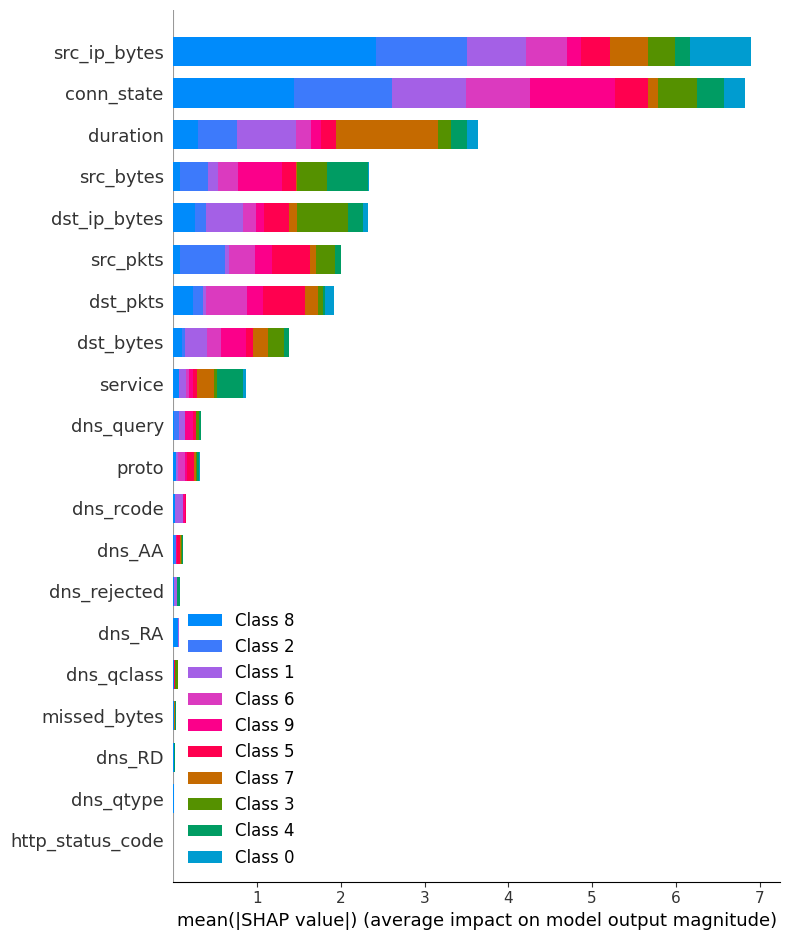

In [6]:
# ---------------------------------------------------------
# Summary plot general
# Muestra impacto global de cada variable
# ---------------------------------------------------------
shap.summary_plot(shap_values, X_shap)

7. Summary plot tipo barra

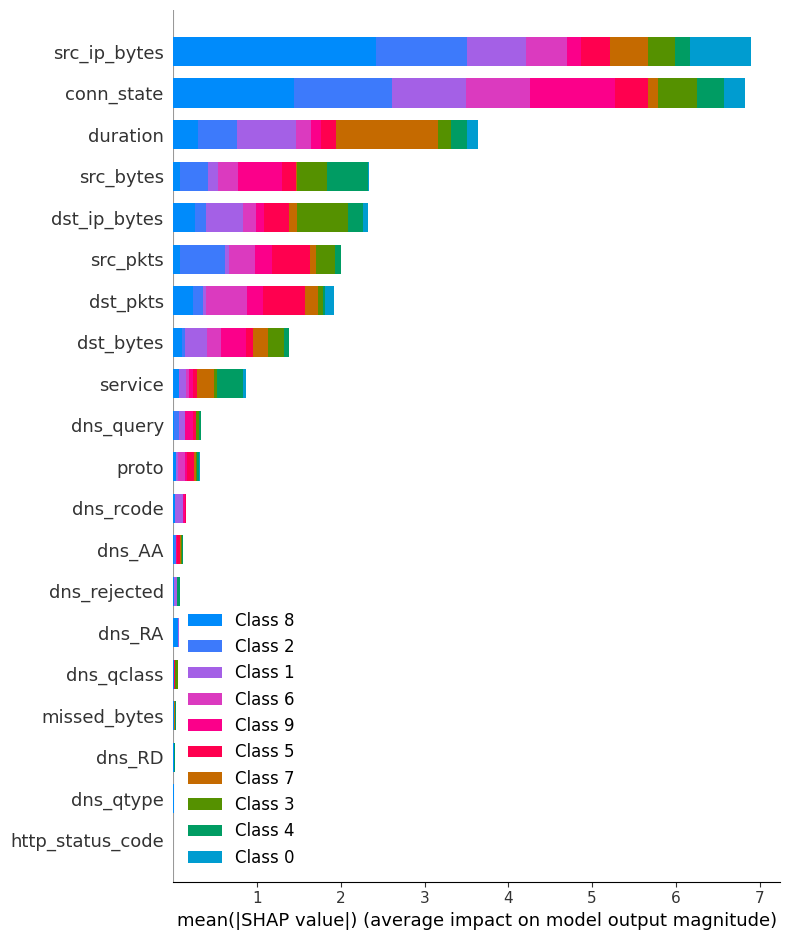

In [7]:
# ---------------------------------------------------------
# Ranking global de variables según SHAP
# ---------------------------------------------------------
shap.summary_plot(shap_values, X_shap, plot_type="bar")

8. Extraer ranking numérico de variables

In [8]:
# ---------------------------------------------------------
# Calcular importancia media absoluta de SHAP
# Para multiclase puede venir en 3 dimensiones:
# (muestras, features, clases)
# ---------------------------------------------------------
if shap_values.values.ndim == 3:
    mean_abs_shap = np.abs(shap_values.values).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

feature_importance_df.head(20)

,feature,mean_abs_shap
8,src_ip_bytes,0.689935
5,conn_state,0.682740
2,duration,0.363461
3,src_bytes,0.233988
10,dst_ip_bytes,0.231976
7,src_pkts,0.199506
9,dst_pkts,0.192077
4,dst_bytes,0.138126
1,service,0.086296
11,dns_query,0.032964


9. Gráfico top 15 variables

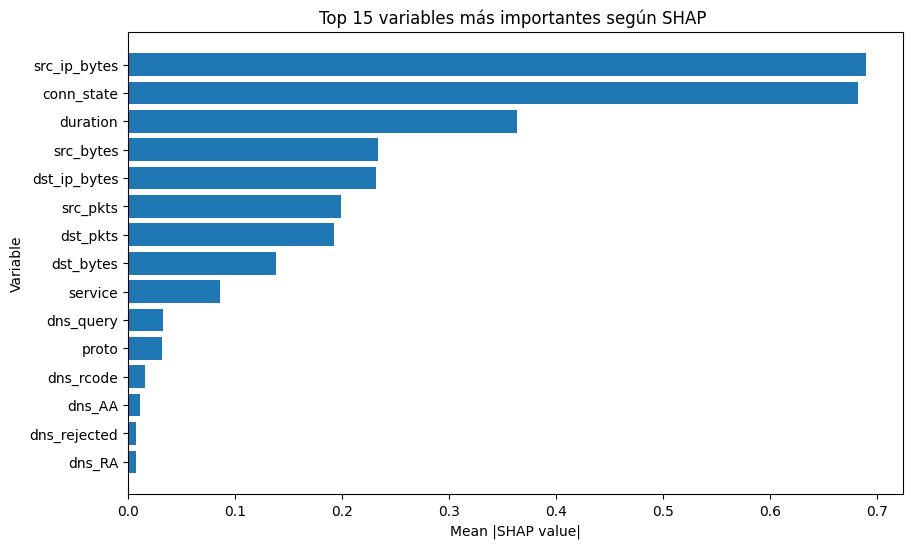

In [9]:
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"][::-1], top_features["mean_abs_shap"][::-1])
plt.title("Top 15 variables más importantes según SHAP ")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Variable")
plt.show()

10. Explicación local de una observación

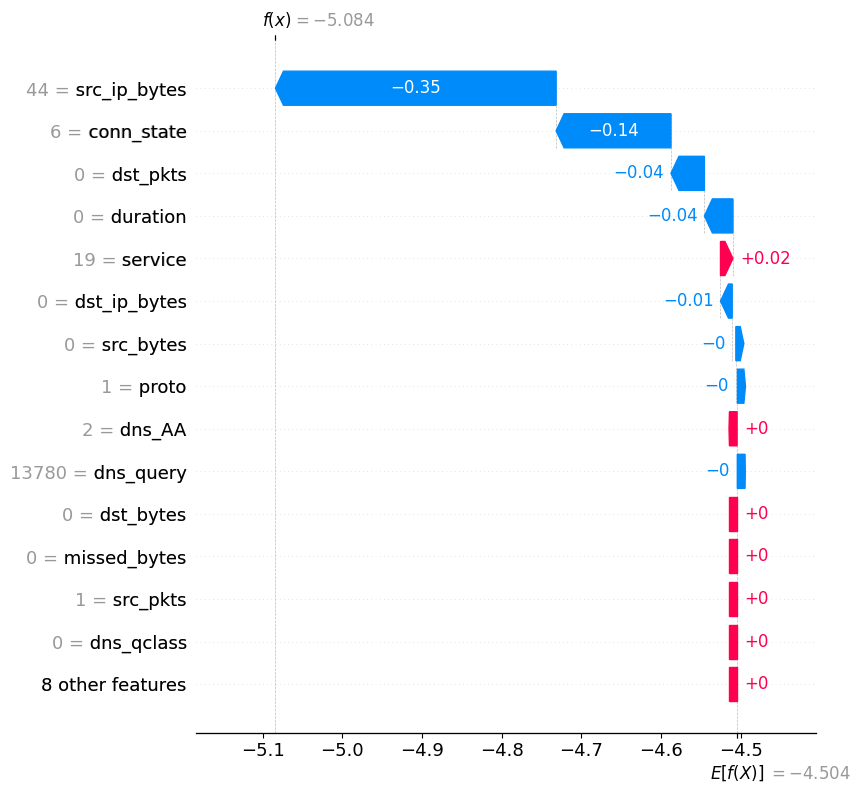

In [10]:
# ---------------------------------------------------------
# Selecciona una observación específica y una clase específica
# ---------------------------------------------------------
sample_index = 0
class_index = 0  # Cambia este valor según la clase que quieras explicar

# ---------------------------------------------------------
# Waterfall plot para una observación y una clase específica
# ---------------------------------------------------------
shap.plots.waterfall(
    shap_values[sample_index, :, class_index],
    max_display=15
)

11. Ver clase real y clase predicha del caso analizado

In [11]:
# Predicción del modelo sobre la muestra SHAP
y_pred_shap = model.predict(X_shap)

# Verdaderos: si y_test ya está en texto, no hace falta inverse_transform
y_true_local = y_test.loc[X_shap.index]

if pd.api.types.is_numeric_dtype(y_true_local):
    y_true_local = target_encoder.inverse_transform(y_true_local.astype(int))
else:
    y_true_local = y_true_local.astype(str).values

# Predicciones: normalmente vienen numéricas, así que sí se decodifican
y_pred_local = target_encoder.inverse_transform(y_pred_shap.astype(int))

results_local = pd.DataFrame({
    "real": y_true_local,
    "pred": y_pred_local
})

results_local.head(10)

,real,pred
0,scanning,scanning
1,dos,dos
2,ddos,ddos
3,scanning,scanning
4,scanning,scanning
5,password,password
6,scanning,scanning
7,ddos,ddos
8,scanning,scanning
9,ddos,ddos


12. Analizar un caso específico

Clase real: password
Clase predicha: password
Índice clase predicha: 6


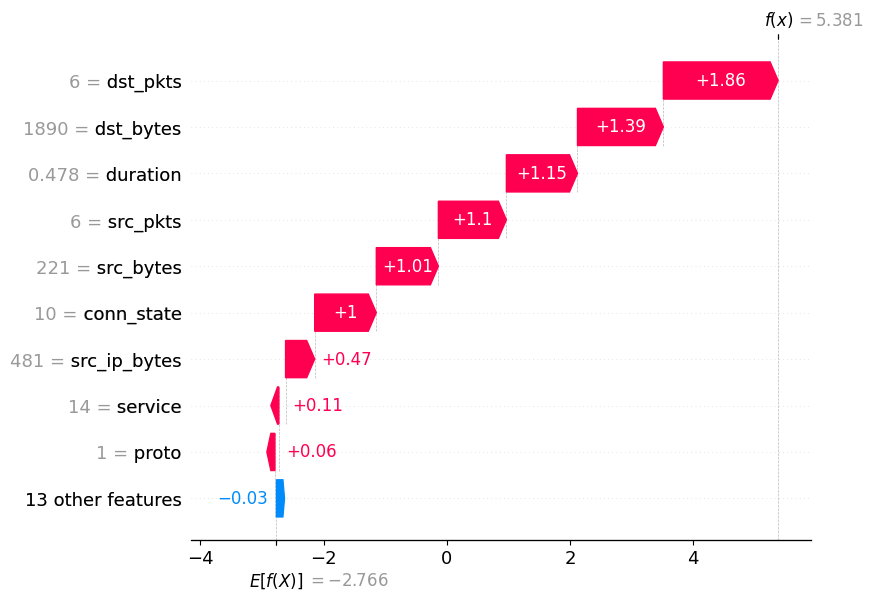

In [12]:
case_idx = 5

print("Clase real:", results_local.iloc[case_idx]["real"])
print("Clase predicha:", results_local.iloc[case_idx]["pred"])

# índice de la clase predicha
pred_class_name = results_local.iloc[case_idx]["pred"]
pred_class_idx = class_names.index(pred_class_name)

print("Índice clase predicha:", pred_class_idx)

# waterfall para esa observación y esa clase
shap.plots.waterfall(shap_values[case_idx, :, pred_class_idx])

13. SHAP por clase específica

Clases disponibles: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Clase objetivo: ddos
Índice: 1


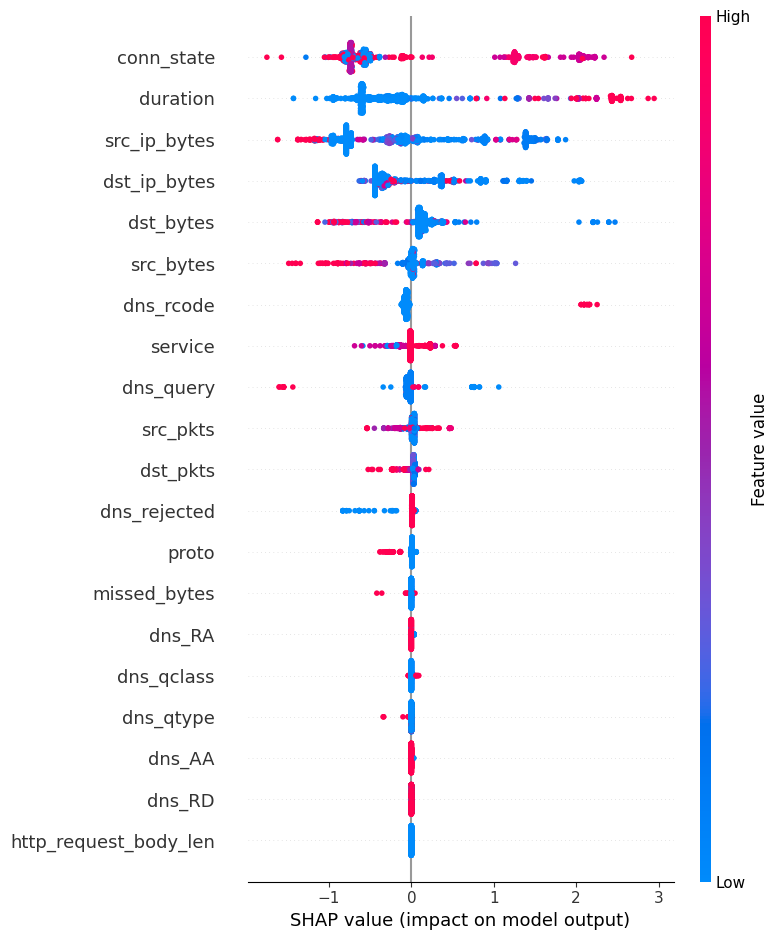

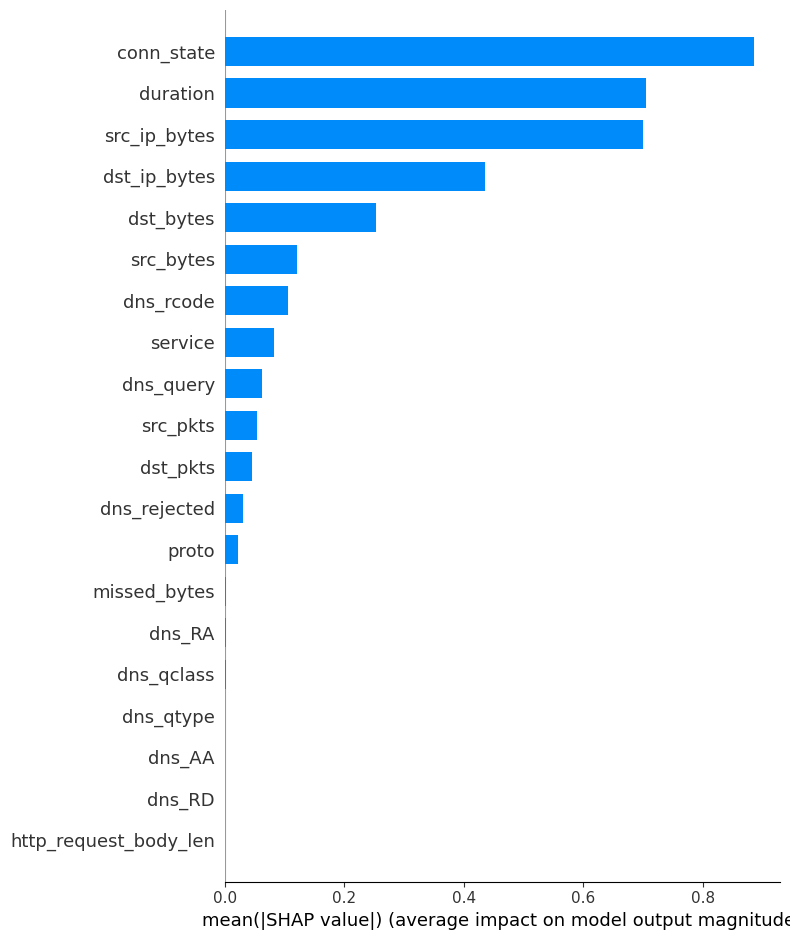

In [13]:
print("Clases disponibles:", class_names)

target_class = "ddos"
class_idx = class_names.index(target_class)

print("Clase objetivo:", target_class)
print("Índice:", class_idx)

shap.summary_plot(shap_values.values[:, :, class_idx], X_shap)

shap.summary_plot(shap_values.values[:, :, class_idx], X_shap, plot_type="bar")

14. Dependence plot de una variable importante

Top feature: src_ip_bytes


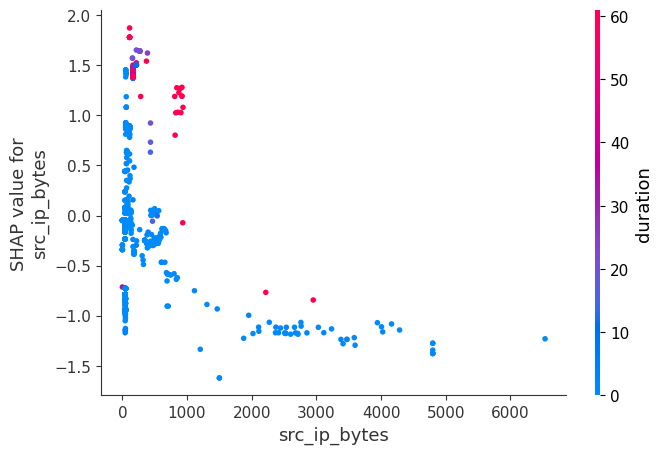

In [14]:
top_feature_name = feature_importance_df.iloc[0]["feature"]
print("Top feature:", top_feature_name)

shap.dependence_plot(
    top_feature_name,
    shap_values.values[:, :, class_idx],
    X_shap
)

15. Guardar ranking SHAP

In [15]:
feature_importance_df.to_csv(
    os.path.join(config.FULL_ARTIFACTS_DIR, "shap_feature_importance_full_xgb.csv"),
    index=False
)

print("Ranking SHAP guardado.")

Ranking SHAP guardado.


16. Guardar gráfico top variables como imagen

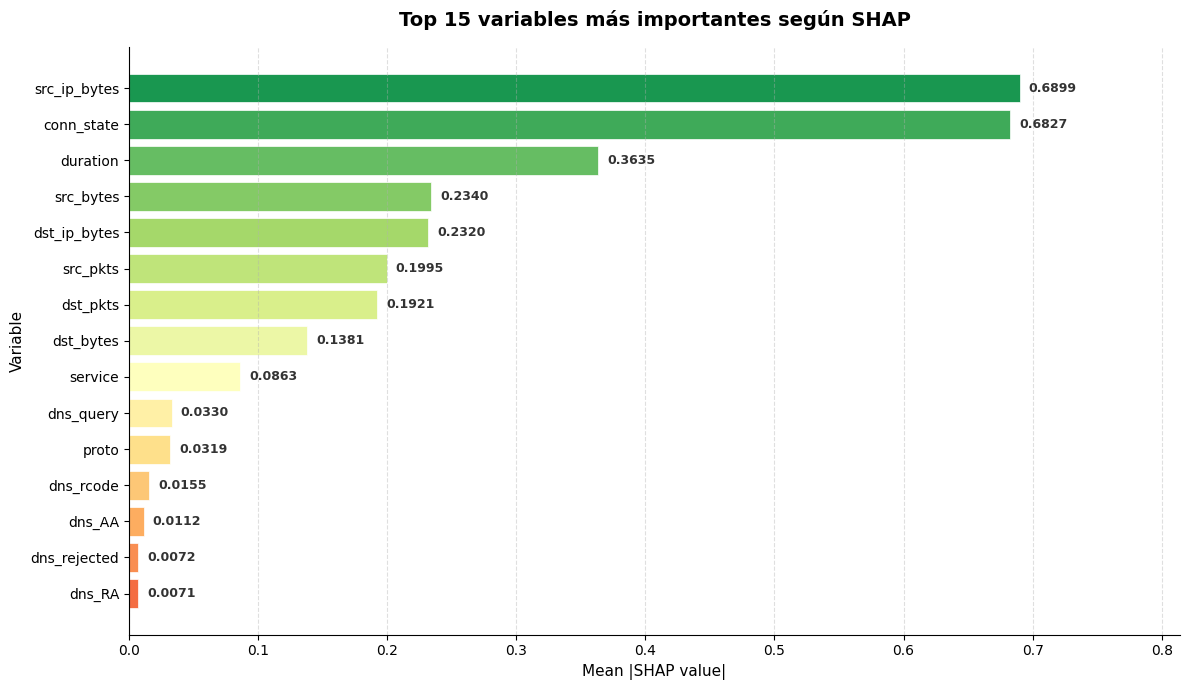

In [17]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

images_dir = os.path.join(PROJECT_ROOT, "images")
os.makedirs(images_dir, exist_ok=True)

# Datos ordenados
features = top_features["feature"][::-1].values
values = top_features["mean_abs_shap"][::-1].values

# Colores degradados (de menor a mayor importancia)
colors = cm.RdYlGn(np.linspace(0.2, 0.9, len(values)))

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(features, values, color=colors, edgecolor="white", linewidth=0.5)

# Valores numéricos al final de cada barra
for bar, val in zip(bars, values):
    ax.text(
        bar.get_width() + max(values) * 0.01,  # posición x (ligeramente a la derecha)
        bar.get_y() + bar.get_height() / 2,     # posición y (centrado)
        f"{val:.4f}",                            # formato del número
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
        color="#333333"
    )

# Estilo
ax.set_title("Top 15 variables más importantes según SHAP", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_ylabel("Variable", fontsize=11)
ax.set_xlim(0, max(values) * 1.18)  # espacio para los números
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    os.path.join(images_dir, "shap_top15_full_xgb.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()